In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("Copy of 1st_group_p_controller(1).csv")

In [6]:
print(df.head())

  Level Control Trainer (UT35A) -17-Mar-2025 15:13:50            .1    .2  \
0                                               Time   Time s  SP %  PV %   
1                                           15:08:26        1    60  60.1   
2                                           15:08:27        2    60    60   
3                                           15:08:28        3    60    60   
4                                           15:08:29        4    60    60   

     .3    .4    .5 Unnamed: 7  
0  OP %  PB %  IT s       DT s  
1  50.1    75     0          0  
2  50.1    75     0          0  
3    50    75     0          0  
4    50    75     0          0  


In [7]:
x_train=df.iloc[1:,:].values

In [8]:
print(x_train)

[['15:08:26' '1' '60' ... '75' '0' '0']
 ['15:08:27' '2' '60' ... '75' '0' '0']
 ['15:08:28' '3' '60' ... '75' '0' '0']
 ...
 ['15:13:45' '318' '60' ... '10' '0' '0']
 ['15:13:45' '319' '60' ... '10' '0' '0']
 ['15:13:46' '320' '60' ... '10' '0' '0']]


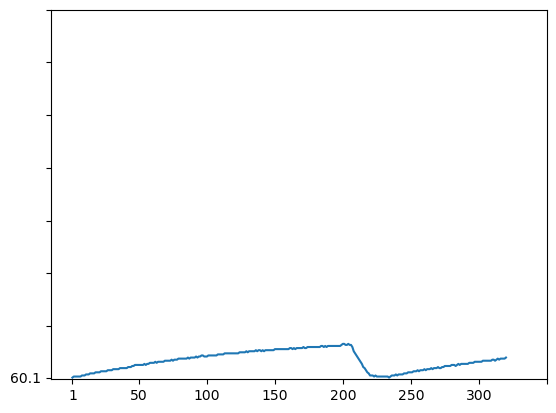

In [9]:
plt.plot(x_train[:,1],x_train[:,3])
plt.xticks([0,49,99,149,199,249,299,349])
plt.yticks([0,49,99,149,199,249,299,349])
plt.show()

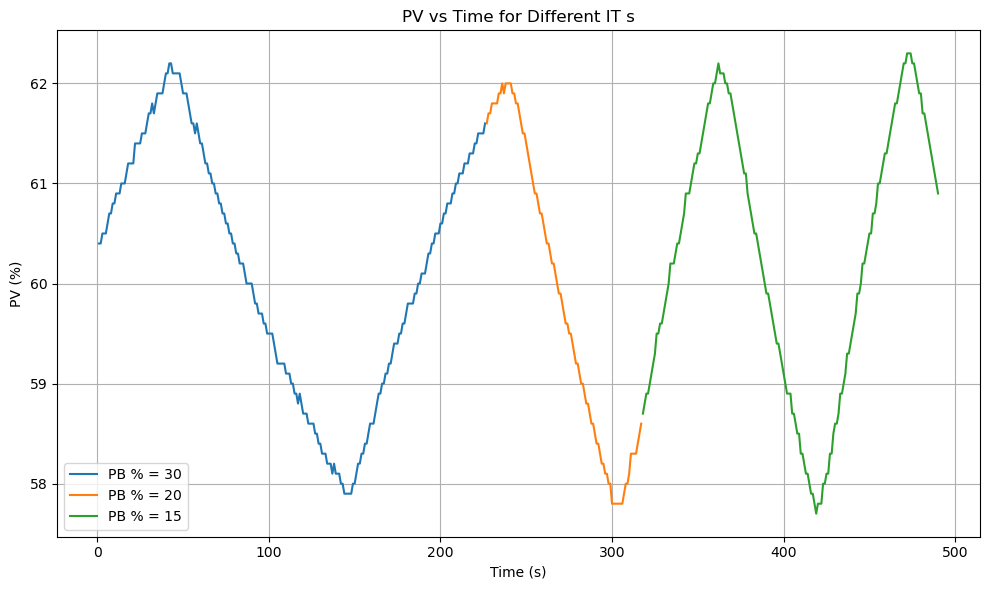

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV using the second row as header
df = pd.read_csv("Copy of 1st group pi controller(1).csv", header=1)

# Convert necessary columns to numeric
df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
df['IT s'] = pd.to_numeric(df['IT s'], errors='coerce')

# Drop rows with missing values in the required columns
df.dropna(subset=['Time s', 'PV %', 'IT s'], inplace=True)

# Plot PV vs Time for each unique PB %
plt.figure(figsize=(10, 6))
for pb in df['IT s'].unique():
    sub_df = df[df['IT s'] == pb]
    plt.plot(sub_df['Time s'], sub_df['PV %'], label=f'PB % = {pb}')

  # Custom x-axis ticks
plt.xlabel('Time (s)')
plt.ylabel('PV (%)')
plt.title('PV vs Time for Different IT s')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\akash kumar shaw\Downloads\pv_vs_time_plot.png

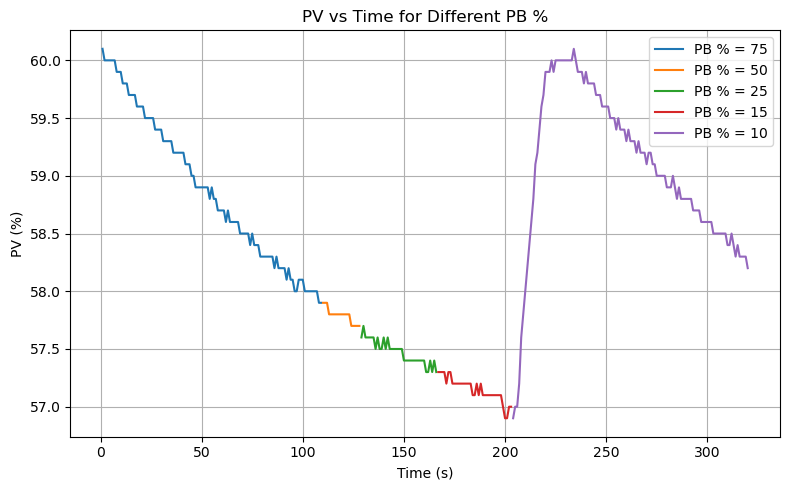

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink

# Load the CSV using the second row as header
df = pd.read_csv("Copy of 1st group p controller(1).csv", header=1)
#Copy of 1st group pi controller(1).csv
# Convert necessary columns to numeric
df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
df['PB %'] = pd.to_numeric(df['PB %'], errors='coerce')

# Drop rows with missing values in the required columns
df.dropna(subset=['Time s', 'PV %', 'PB %'], inplace=True)

# Plot PV vs Time for each unique PB %
plt.figure(figsize=(8, 5))
for pb in df['PB %'].unique():
    sub_df = df[df['PB %'] == pb]
    plt.plot(sub_df['Time s'], sub_df['PV %'], label=f'PB % = {pb}')
   
 # Custom x-axis ticks
plt.xlabel('Time (s)')
plt.ylabel('PV (%)')
plt.title('PV vs Time for Different PB %')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the figure
file_name = "pv_vs_time_plot.png"
plt.savefig(file_name, dpi=300)

# Display download link (works in Jupyter Notebook)
FileLink(file_name)


In [3]:
import pandas as pd
import numpy as np

# Load the CSV file
df = pd.read_csv("Copy of 1st_group_p_controller(1).csv", header=1)

# Convert to numeric values
df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')

# Drop NaN values
df.dropna(subset=['Time s', 'PV %'], inplace=True)

# Extract time and PV data
time = df["Time s"].values
pv = df["PV %"].values

# Define final value and settling tolerance (within ±2% of final value)
final_value = pv[-1]
tolerance = 0.02 * final_value

# Find the first time PV settles within the tolerance band and stays there
settled_index = np.where(np.abs(pv - final_value) < tolerance)[0]
settling_time = time[settled_index[0]] if len(settled_index) > 0 else None

# Compute steady-state error
setpoint = pv[0]  # Assuming the initial PV is the desired setpoint
steady_state_error = np.abs(setpoint - final_value)

# Compute overshoot percentage
peak_value = np.max(pv)
overshoot = ((peak_value - final_value) / final_value) * 100

# Print results
print(f"Settling Time: {settling_time} sec")
print(f"Steady-State Error: {steady_state_error} %")
print(f"Overshoot: {overshoot:.2f} %")


Settling Time: 31 sec
Steady-State Error: 1.8999999999999986 %
Overshoot: 3.26 %


In [11]:
df=pd.read_csv("PI effect g11.csv")

In [12]:
print(df.head())

  Flow Control Trainer (UT35A) -24-Mar-2025 15:45:47            .1    .2  \
0                                               Time  Time s  SP %  PV %   
1                                           15:25:23       1    50  51.4   
2                                           15:25:24       2    50  51.3   
3                                           15:25:25       3    50  51.3   
4                                           15:25:26       4    50  51.2   

     .3    .4    .5 Unnamed: 7  
0  OP %  PB %  IT s       DT s  
1  46.5   100    20          0  
2  46.6   100    20          0  
3  46.6   100    20          0  
4  46.5   100    20          0  


In [22]:
x_train=df.iloc[1:,1].values
y_train=df.iloc[1:,3].values

In [23]:
print(x_train)

['1' '2' '3' ... '1217' '1218' '1219']


In [24]:
print(y_train[360])

50.8


In [26]:
print(x_train[:,0])

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [33]:
import pandas as pd
import numpy as np

# Load the CSV file
df = pd.read_csv("PI effect g11.csv", header=1)

# Convert to numeric values
df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')

# Drop NaN values
df.dropna(subset=['Time s', 'PV %'], inplace=True)

# Extract time and PV data
time = df["Time s"].values
pv = df["PV %"].values

# Define final value and settling tolerance (within ±2% of final value)
final_value = pv[-1]
tolerance = 0.02 * final_value

# Find the first time PV settles within the tolerance band and stays there
settled_index = np.where(np.abs(pv - final_value) < tolerance)[0]
settling_time = time[settled_index[0]] if len(settled_index) > 0 else None

# Compute steady-state error
setpoint = pv[0]  # Assuming the initial PV is the desired setpoint
steady_state_error = np.abs(setpoint - final_value)

# Compute overshoot percentage
peak_value = np.max(pv)
overshoot = ((peak_value - final_value) / final_value) * 100

# Print results
print(f"Settling Time: {settling_time} sec")
print(f"Steady-State Error: {steady_state_error} %")
print(f"Overshoot: {overshoot:.2f} %")


Settling Time: 1 sec
Steady-State Error: 0.7999999999999972 %
Overshoot: 60.67 %


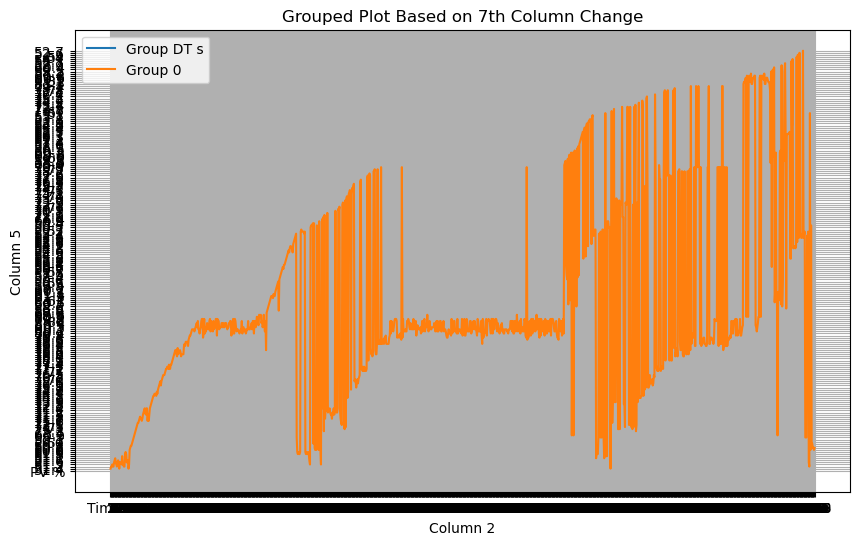

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
df = pd.read_csv("PI effect g11.csv")

# Extract the necessary columns
col2 = df.iloc[:, 1]  # 2nd column (index 1)
col5 = df.iloc[:, 3]  # 5th column (index 4)
col7 = df.iloc[:, 7]  # 7th column (index 6)

# Combine into a DataFrame for easy processing
data = pd.DataFrame({
    'X': col2,
    'Y': col5,
    'Group': col7
})

# Group by changes in the 7th column
group_id = (data['Group'] != data['Group'].shift()).cumsum()

# Plot each group on the same graph
plt.figure(figsize=(10, 6))
for _, group in data.groupby(group_id):
    plt.plot(group['X'].values, group['Y'].values, label=f'Group {group["Group"].iloc[0]}')

plt.xlabel("Column 2")
plt.ylabel("Column 5")
plt.title("Grouped Plot Based on 7th Column Change")
plt.legend()
plt.grid(True)
plt.show()


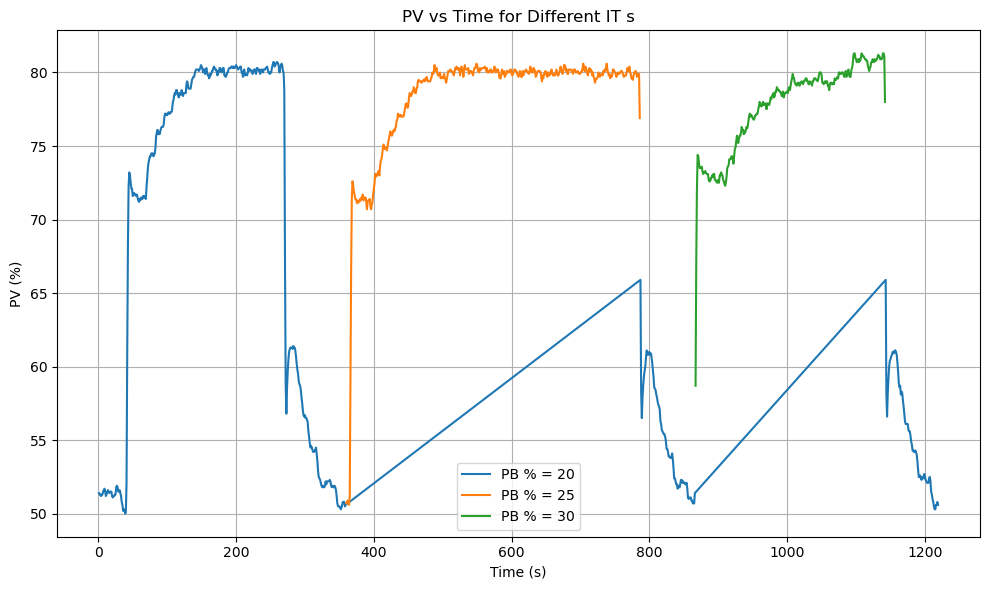

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV using the second row as header
df = pd.read_csv("PI effect g11.csv", header=1)

# Convert necessary columns to numeric
df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
df['IT s'] = pd.to_numeric(df['IT s'], errors='coerce')

# Drop rows with missing values in the required columns
df.dropna(subset=['Time s', 'PV %', 'IT s'], inplace=True)

# Plot PV vs Time for each unique PB %
plt.figure(figsize=(10, 6))
for pb in df['IT s'].unique():
    sub_df = df[df['IT s'] == pb]
    plt.plot(sub_df['Time s'], sub_df['PV %'], label=f'PB % = {pb}')

  # Custom x-axis ticks
plt.xlabel('Time (s)')
plt.ylabel('PV (%)')
plt.title('PV vs Time for Different IT s')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

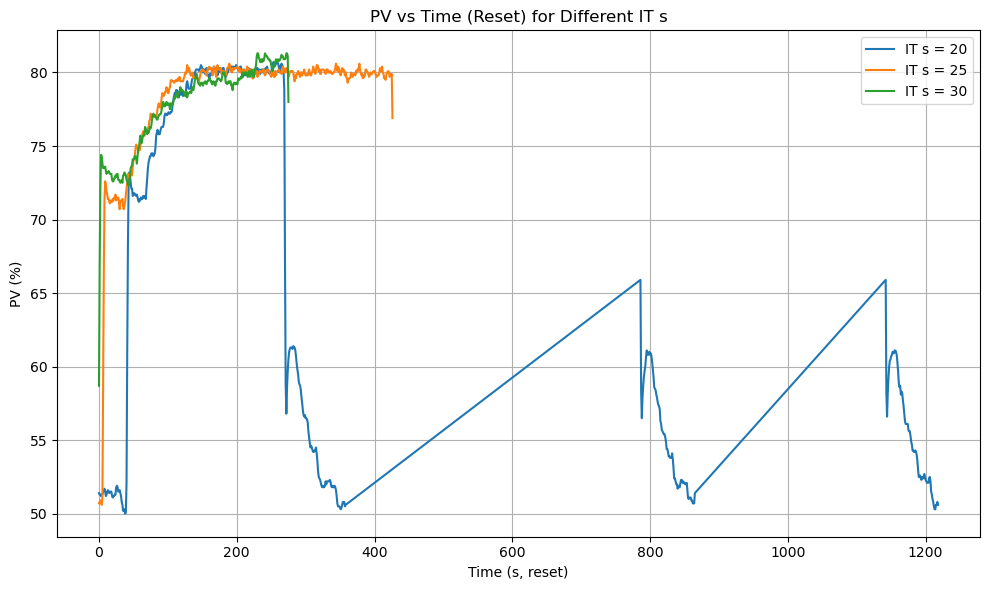

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV using the second row as header
df = pd.read_csv("PI effect g11.csv", header=1)

# Convert necessary columns to numeric
df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
df['IT s'] = pd.to_numeric(df['IT s'], errors='coerce')

# Drop rows with missing values in the required columns
df.dropna(subset=['Time s', 'PV %', 'IT s'], inplace=True)

# Plot PV vs Time (reset to 0) for each unique IT s
plt.figure(figsize=(10, 6))
for pb in df['IT s'].unique():
    sub_df = df[df['IT s'] == pb].copy()
    sub_df['Time s'] -= sub_df['Time s'].iloc[0]  # Reset time to start at 0
    plt.plot(sub_df['Time s'], sub_df['PV %'], label=f'IT s = {pb}')

# Labels and formatting
plt.xlabel('Time (s, reset)')
plt.ylabel('PV (%)')
plt.title('PV vs Time (Reset) for Different IT s')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


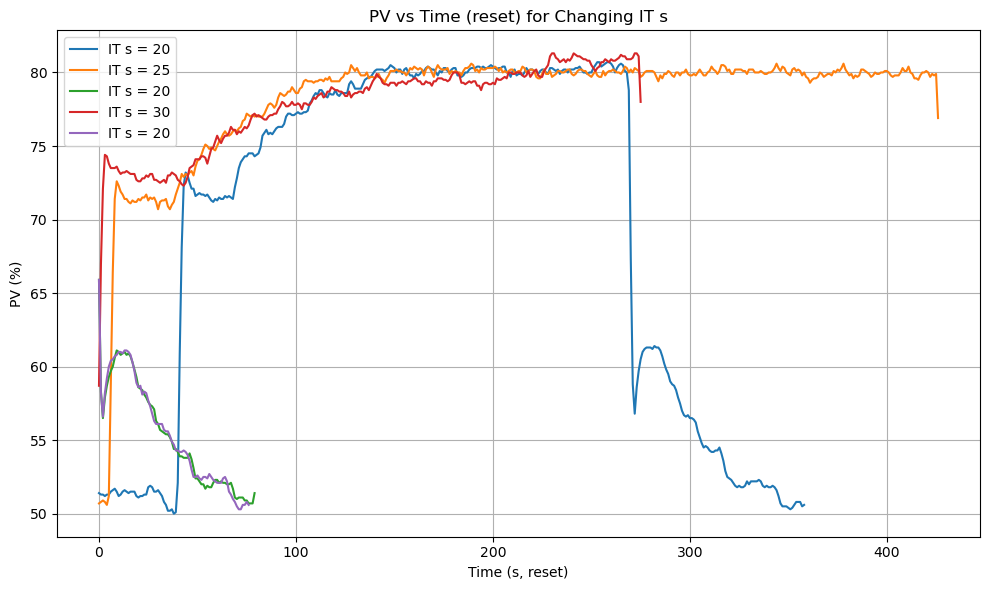

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV using the second row as header
df = pd.read_csv("PI effect g11.csv", header=1)

# Convert necessary columns to numeric
df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
df['IT s'] = pd.to_numeric(df['IT s'], errors='coerce')

# Drop rows with missing values in the required columns
df.dropna(subset=['Time s', 'PV %', 'IT s'], inplace=True)

# Group by change points in 'IT s'
df['group_id'] = (df['IT s'] != df['IT s'].shift()).cumsum()

# Plot each group
plt.figure(figsize=(10, 6))
for _, group in df.groupby('group_id'):
    label = f"IT s = {group['IT s'].iloc[0]}"
    time_reset = group['Time s'] - group['Time s'].iloc[0]
    plt.plot(time_reset, group['PV %'], label=label)

# Labels and formatting
plt.xlabel('Time (s, reset)')
plt.ylabel('PV (%)')
plt.title('PV vs Time (reset) for Changing IT s')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


IT s = 20:
  Rise Time: 4 s
  Overshoot: 0.75 %

IT s = 25:
  Rise Time: 5 s
  Overshoot: 1.0 %

IT s = 20:
  Rise Time: 0 s
  Overshoot: 0.0 %

IT s = 30:
  Rise Time: 3 s
  Overshoot: 0.0 %



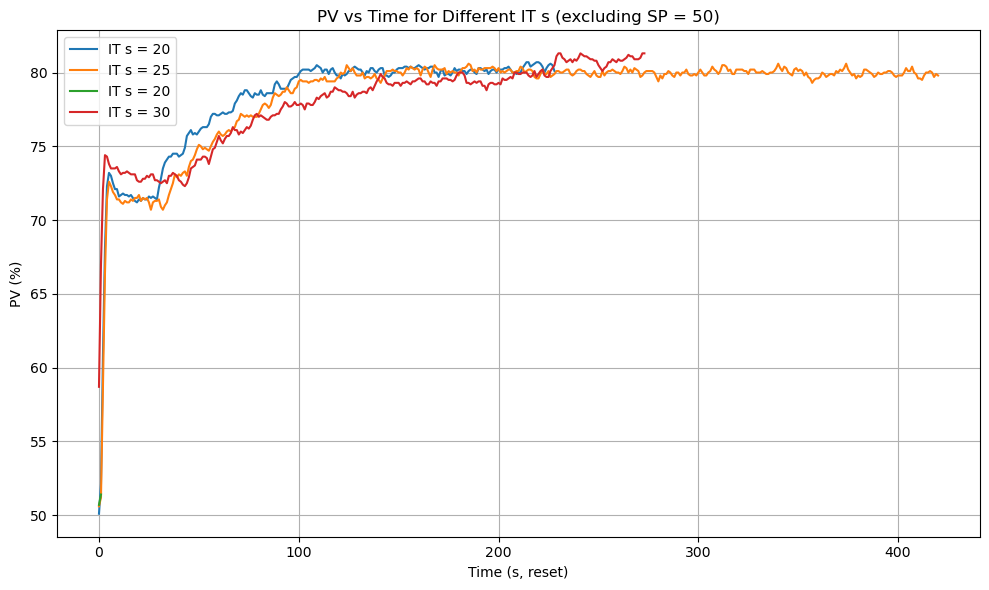

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv("PI effect g11.csv", header=1)

# Convert columns to numeric
df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
df['IT s'] = pd.to_numeric(df['IT s'], errors='coerce')
df['SP %'] = pd.to_numeric(df['SP %'], errors='coerce')

# Drop missing rows
df.dropna(subset=['Time s', 'PV %', 'IT s', 'SP %'], inplace=True)

# Mark segments where IT s changes
df['group_id'] = (df['IT s'] != df['IT s'].shift()).cumsum()

# Plot
plt.figure(figsize=(10, 6))

for group_index, group in df.groupby('group_id'):
    it_val = group['IT s'].iloc[0]
    label = f"IT s = {it_val}"

    # Filter out only the rows where SP != 50
    group = group[group['SP %'] != 50]

    if group.empty:
        continue

    # Reset time to 0
    time_reset = group['Time s'] - group['Time s'].iloc[0]
    pv = group['PV %'].values

    # Plot
    plt.plot(time_reset, pv, label=label)

    # --- Rise Time & Overshoot ---
    final_val = pv[-1]
    rise_start_val = 0.1 * final_val
    rise_end_val = 0.9 * final_val

    t_start_series = time_reset[group['PV %'] >= rise_start_val]
    t_end_series = time_reset[group['PV %'] >= rise_end_val]

    if not t_start_series.empty and not t_end_series.empty:
        rise_time = t_end_series.iloc[0] - t_start_series.iloc[0]
        rise_time = round(rise_time, 2)
    else:
        rise_time = "N/A"

    overshoot = round((pv.max() - final_val) / final_val * 100, 2)

    # Print results
    print(f"{label}:")
    print(f"  Rise Time: {rise_time} s")
    print(f"  Overshoot: {overshoot} %\n")

# Final plot settings
plt.xlabel('Time (s, reset)')
plt.ylabel('PV (%)')
plt.title('PV vs Time for Different IT s (excluding SP = 50)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


IT s = 20:
  Rise Time: 4 s
  Overshoot: 0.75 %

IT s = 25:
  Rise Time: 5 s
  Overshoot: 1.0 %

IT s = 20:
  Rise Time: 0 s
  Overshoot: 0.0 %

IT s = 30:
  Rise Time: 3 s
  Overshoot: 0.0 %



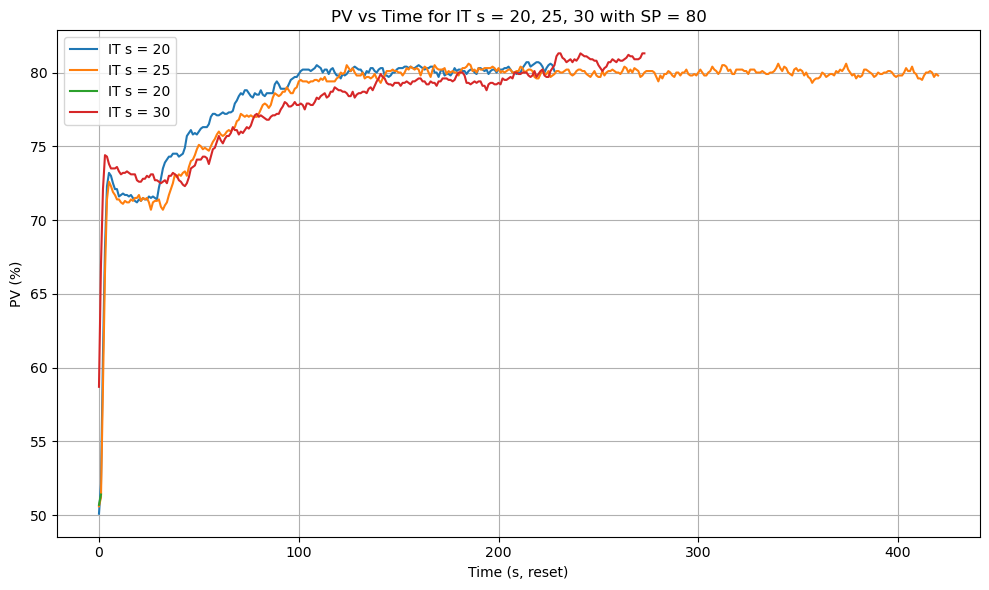

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv("PI effect g11.csv", header=1)

# Convert columns to numeric
df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
df['IT s'] = pd.to_numeric(df['IT s'], errors='coerce')
df['SP %'] = pd.to_numeric(df['SP %'], errors='coerce')

# Drop missing rows
df.dropna(subset=['Time s', 'PV %', 'IT s', 'SP %'], inplace=True)

# Filter only rows with SP = 80 and IT s in [20, 25, 30]
df = df[(df['SP %'] == 80) & (df['IT s'].isin([20, 25, 30]))]

# Mark segments where IT s changes
df['group_id'] = (df['IT s'] != df['IT s'].shift()).cumsum()

# Plot
plt.figure(figsize=(10, 6))

for group_index, group in df.groupby('group_id'):
    it_val = group['IT s'].iloc[0]
    label = f"IT s = {it_val}"

    # Reset time to 0
    time_reset = group['Time s'] - group['Time s'].iloc[0]
    pv = group['PV %'].values

    # Plot
    plt.plot(time_reset, pv, label=label)

    # --- Rise Time & Overshoot ---
    final_val = pv[-1]
    rise_start_val = 0.1 * final_val
    rise_end_val = 0.9 * final_val

    t_start_series = time_reset[group['PV %'] >= rise_start_val]
    t_end_series = time_reset[group['PV %'] >= rise_end_val]

    if not t_start_series.empty and not t_end_series.empty:
        rise_time = t_end_series.iloc[0] - t_start_series.iloc[0]
        rise_time = round(rise_time, 2)
    else:
        rise_time = "N/A"

    overshoot = round((pv.max() - final_val) / final_val * 100, 2)

    # Print results
    print(f"{label}:")
    print(f"  Rise Time: {rise_time} s")
    print(f"  Overshoot: {overshoot} %\n")

# Final plot settings
plt.xlabel('Time (s, reset)')
plt.ylabel('PV (%)')
plt.title('PV vs Time for IT s = 20, 25, 30 with SP = 80')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


IT s = 20:
  Rise Time: 4 s
  Overshoot: 0.75 %

IT s = 25:
  Rise Time: 5 s
  Overshoot: 1.0 %

IT s = 30:
  Rise Time: 3 s
  Overshoot: 0.0 %



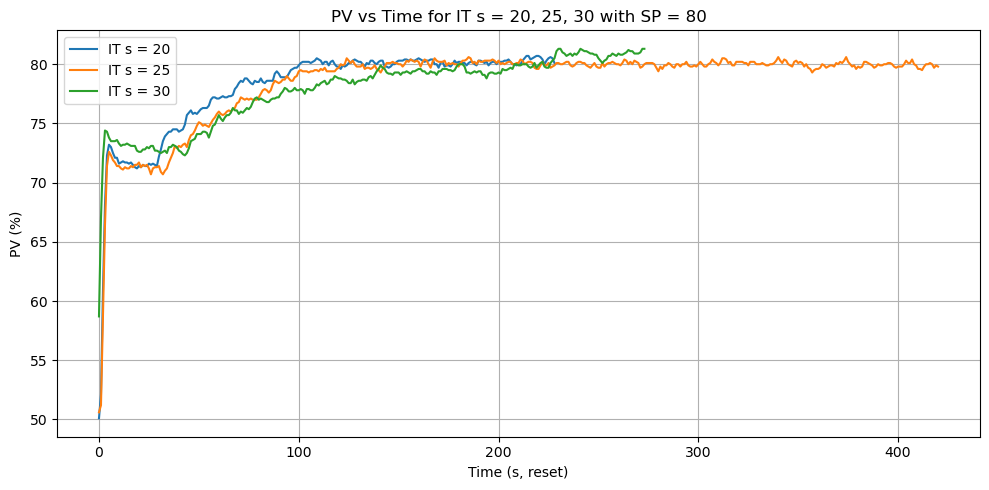

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv("PI effect g11.csv", header=1)

# Convert columns to numeric
df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
df['IT s'] = pd.to_numeric(df['IT s'], errors='coerce')
df['SP %'] = pd.to_numeric(df['SP %'], errors='coerce')

# Drop missing values
df.dropna(subset=['Time s', 'PV %', 'IT s', 'SP %'], inplace=True)

# Filter for SP % = 80 and IT s in [20, 25, 30]
filtered_df = df[(df['SP %'] == 80) & (df['IT s'].isin([20, 25, 30]))].copy()

# Add group when IT s or SP % changes
filtered_df['group_change'] = (filtered_df['IT s'] != filtered_df['IT s'].shift()) | (filtered_df['SP %'] != filtered_df['SP %'].shift())
filtered_df['group_id'] = filtered_df['group_change'].cumsum()

# Track plotted IT s values
plotted_its = set()

plt.figure(figsize=(10, 5))

for group_id, group in filtered_df.groupby('group_id'):
    it_val = group['IT s'].iloc[0]
    sp_val = group['SP %'].iloc[0]

    # Plot only the first occurrence of each IT s
    if it_val in plotted_its:
        continue
    plotted_its.add(it_val)

    # Reset time
    time_reset = group['Time s'] - group['Time s'].iloc[0]
    pv = group['PV %'].values

    # Plot
    plt.plot(time_reset, pv, label=f"IT s = {it_val}")

    # Calculate rise time and overshoot
    final_val = pv[-1]
    rise_start_val = 0.1 * final_val
    rise_end_val = 0.9 * final_val

    t_start_series = time_reset[group['PV %'] >= rise_start_val]
    t_end_series = time_reset[group['PV %'] >= rise_end_val]

    if not t_start_series.empty and not t_end_series.empty:
        rise_time = round(t_end_series.iloc[0] - t_start_series.iloc[0], 2)
    else:
        rise_time = "N/A"

    overshoot = round((pv.max() - final_val) / final_val * 100, 2)

    # Print results
    print(f"IT s = {it_val}:")
    print(f"  Rise Time: {rise_time} s")
    print(f"  Overshoot: {overshoot} %\n")

# Plot formatting
plt.xlabel("Time (s, reset)")
plt.ylabel("PV (%)")
plt.title("PV vs Time for IT s = 20, 25, 30 with SP = 80")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


DT s = 1.0:
  Rise Time: 8 s
  Overshoot: 0.62 %

DT s = 1.5:
  Rise Time: 30 s
  Overshoot: 0.37 %

DT s = 2.0:
  Rise Time: 14 s
  Overshoot: 0.0 %



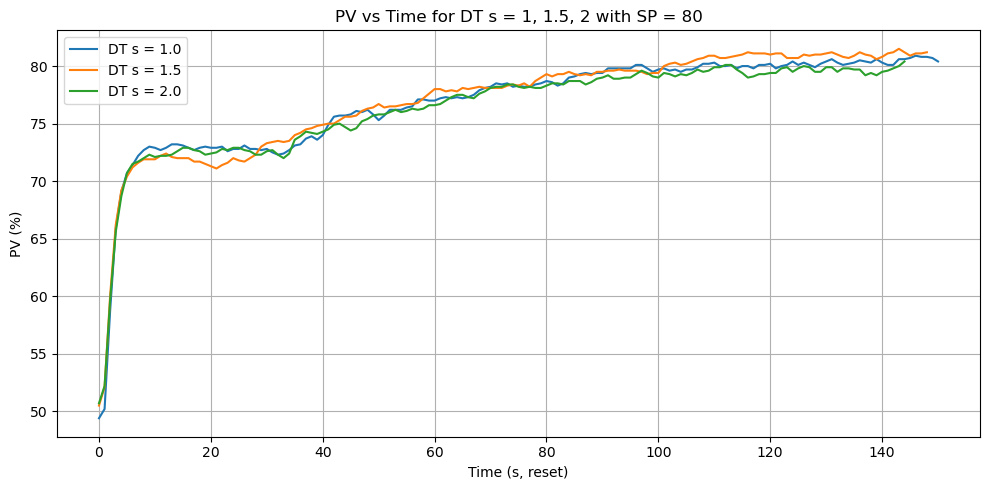

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv("PID effect g11.csv", header=1)

# Convert columns to numeric
df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
df['DT s'] = pd.to_numeric(df['DT s'], errors='coerce')
df['SP %'] = pd.to_numeric(df['SP %'], errors='coerce')

# Drop missing values
df.dropna(subset=['Time s', 'PV %', 'DT s', 'SP %'], inplace=True)

# Filter for SP % = 80 and DT s in [1, 1.5, 2]
filtered_df = df[(df['SP %'] == 80) & (df['DT s'].isin([1, 1.5, 2]))].copy()

# Add group when DT s or SP % changes
filtered_df['group_change'] = (filtered_df['DT s'] != filtered_df['DT s'].shift()) | (filtered_df['SP %'] != filtered_df['SP %'].shift())
filtered_df['group_id'] = filtered_df['group_change'].cumsum()

# Track plotted DT s values
plotted_dts = set()

plt.figure(figsize=(10, 5))

for group_id, group in filtered_df.groupby('group_id'):
    dt_val = group['DT s'].iloc[0]
    sp_val = group['SP %'].iloc[0]

    # Plot only the first occurrence of each DT s
    if dt_val in plotted_dts:
        continue
    plotted_dts.add(dt_val)

    # Reset time
    time_reset = group['Time s'] - group['Time s'].iloc[0]

    # If DT s == 1, exclude data after t = 150s
    if dt_val == 1:
        mask = time_reset <= 150
        group = group[mask]
        time_reset = time_reset[mask]

    pv = group['PV %'].values

    # Plot
    plt.plot(time_reset, pv, label=f"DT s = {dt_val}")

    # Calculate rise time and overshoot
    if len(pv) > 0:
        final_val = pv[-1]
        rise_start_val = 0.1 * final_val
        rise_end_val = 0.9 * final_val

        t_start_series = time_reset[group['PV %'] >= rise_start_val]
        t_end_series = time_reset[group['PV %'] >= rise_end_val]

        if not t_start_series.empty and not t_end_series.empty:
            rise_time = round(t_end_series.iloc[0] - t_start_series.iloc[0], 2)
        else:
            rise_time = "N/A"

        overshoot = round((pv.max() - final_val) / final_val * 100, 2)
    else:
        rise_time = "N/A"
        overshoot = "N/A"

    # Print results
    print(f"DT s = {dt_val}:")
    print(f"  Rise Time: {rise_time} s")
    print(f"  Overshoot: {overshoot} %\n")

# Plot formatting
plt.xlabel("Time (s, reset)")
plt.ylabel("PV (%)")
plt.title("PV vs Time for DT s = 1, 1.5, 2 with SP = 80")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Unique SP % values: [50 80]
Unique PB % values: [100  66]
PB % = 100:
  Rise Time: 3 s
  Overshoot: 3.18 %

PB % = 66:
  Rise Time: 3 s
  Overshoot: 4.1 %



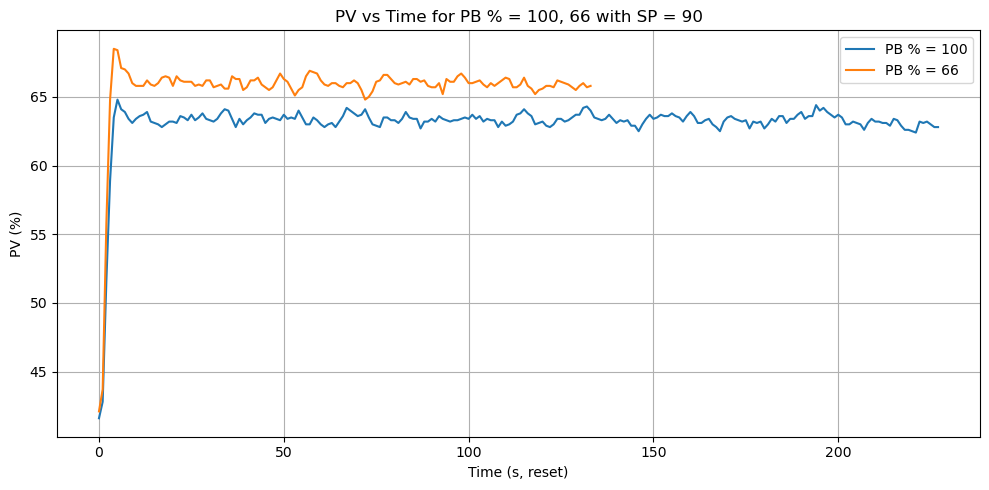

In [60]:

#df = pd.read_csv("", header=1)

import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv("Copy of P_effect_g12(1).csv", header=1)

# Clean column names
df.columns = df.columns.str.strip()

# Convert columns to numeric
df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
df['PB %'] = pd.to_numeric(df['PB %'], errors='coerce')
df['SP %'] = pd.to_numeric(df['SP %'], errors='coerce')

# Drop missing values
df.dropna(subset=['Time s', 'PV %', 'PB %', 'SP %'], inplace=True)

# Debug print to see values
print("Unique SP % values:", df['SP %'].unique())
print("Unique PB % values:", df['PB %'].unique())

# Filter for SP % = 90 and PB % in [100, 66, 50]
filtered_df = df[(df['SP %'] == 80) & (df['PB %'].isin([100, 66, 50]))].copy()

if filtered_df.empty:
    print("No matching data found for SP % = 90 and PB % = 100, 66, 50")
else:
    # Add group id when PB % or SP % changes
    filtered_df['group_change'] = (filtered_df['PB %'] != filtered_df['PB %'].shift()) | (filtered_df['SP %'] != filtered_df['SP %'].shift())
    filtered_df['group_id'] = filtered_df['group_change'].cumsum()

    plotted_pb = set()
    plt.figure(figsize=(10, 5))

    for group_id, group in filtered_df.groupby('group_id'):
        pb_val = group['PB %'].iloc[0]

        if pb_val in plotted_pb:
            continue
        plotted_pb.add(pb_val)

        time_reset = group['Time s'] - group['Time s'].iloc[0]
        pv = group['PV %'].values

        plt.plot(time_reset, pv, label=f"PB % = {pb_val}")

        final_val = pv[-1]
        rise_start_val = 0.1 * final_val
        rise_end_val = 0.9 * final_val

        t_start_series = time_reset[group['PV %'] >= rise_start_val]
        t_end_series = time_reset[group['PV %'] >= rise_end_val]

        if not t_start_series.empty and not t_end_series.empty:
            rise_time = round(t_end_series.iloc[0] - t_start_series.iloc[0], 2)
        else:
            rise_time = "N/A"

        overshoot = round((pv.max() - final_val) / final_val * 100, 2)

        print(f"PB % = {pb_val}:")
        print(f"  Rise Time: {rise_time} s")
        print(f"  Overshoot: {overshoot} %\n")

    plt.xlabel("Time (s, reset)")
    plt.ylabel("PV (%)")
    plt.title("PV vs Time for PB % = 100, 66 with SP = 90")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [64]:
df=pd.read_csv("1april2025 p mode.csv")

In [69]:
x=df.iloc[:,:].values

In [70]:
print(df.head())

  Temperature Control Trainer (UT35A) -01-Apr-2025 02:39:35            .1  \
0                                               Time         Time s  SP %   
1                                           02:36:52              1    42   
2                                           02:36:53              2    42   
3                                           02:36:54              3    42   
4                                           02:36:55              4    42   

     .2    .3    .4    .5 Unnamed: 7  
0  PV %  OP %  PB %  IT s       DT s  
1  34.2  89.2    20     0          0  
2  34.2  89.2    20     0          0  
3  34.2  89.2    20     0          0  
4  34.2  89.2    20     0          0  


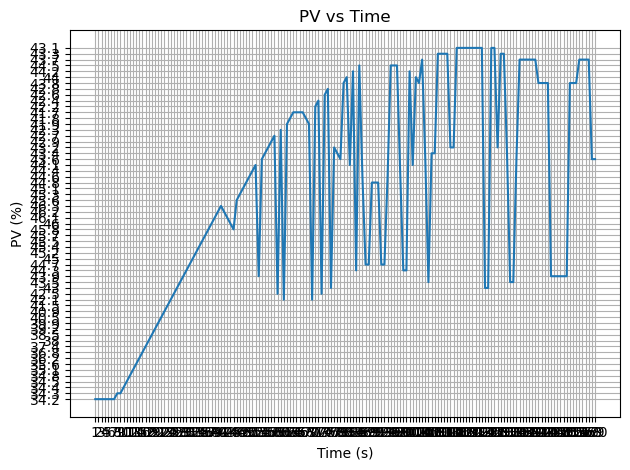

In [93]:



 
# Axis labels, title, grid, etc.
plt.xlabel("Time (s)")
plt.ylabel("PV (%)")
plt.title("PV vs Time")
plt.grid(True)

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


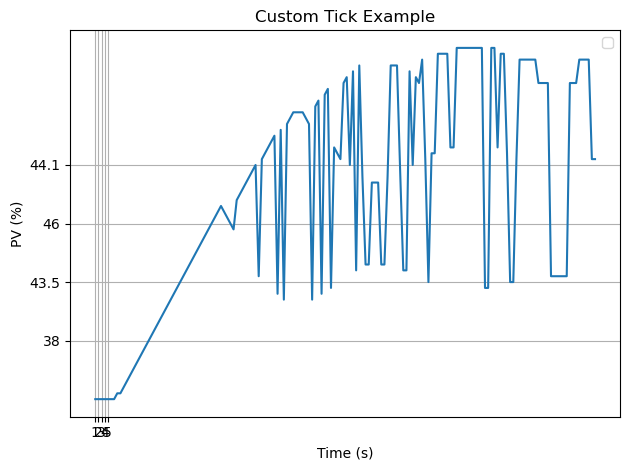

In [94]:
plt.plot(x[1:161,1],x[1:161,3])

# Set custom ticks that you want to see on the axes
plt.xticks([0, 1, 2, 3, 4])           # x-axis ticks you want
plt.yticks([10, 20, 30, 40])          # y-axis ticks you want

# Labels and formatting
plt.xlabel("Time (s)")
plt.ylabel("PV (%)")
plt.title("Custom Tick Example")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


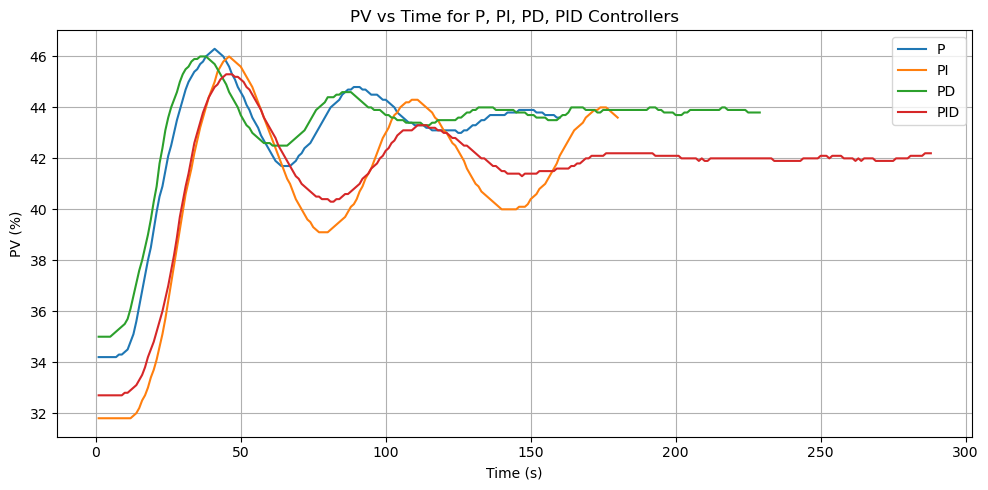

In [101]:
import matplotlib.pyplot as plt

# Load the raw file
with open("1april2025 p mode.csv", "r") as file:
    lines = file.readlines()

# Split sections whenever "Temperature Control Trainer" line appears
sections = []
current_section = []

for line in lines:
    if "Temperature Control Trainer" in line:
        if current_section:
            sections.append(current_section)
        current_section = [line]
    else:
        current_section.append(line)

if current_section:
    sections.append(current_section)

# Labels for controllers
controller_labels = ['P', 'PI', 'PD', 'PID']

# Plotting
plt.figure(figsize=(10, 5))

for idx, section in enumerate(sections):
    from io import StringIO
    csv_data = ''.join(section[1:])  # Skip metadata row

    try:
        import pandas as pd
        df = pd.read_csv(StringIO(csv_data))
        df = df[['Time s', 'PV %']].dropna()
        df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
        df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')

        label = controller_labels[idx] if idx < len(controller_labels) else f"Block {idx+1}"
        plt.plot(df['Time s'], df['PV %'], label=label)

    except Exception as e:
        print(f"Error processing section {idx+1}: {e}")

# Axis and labels
plt.xlabel("Time (s)")
plt.ylabel("PV (%)")
plt.title("PV vs Time for P, PI, PD, PID Controllers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


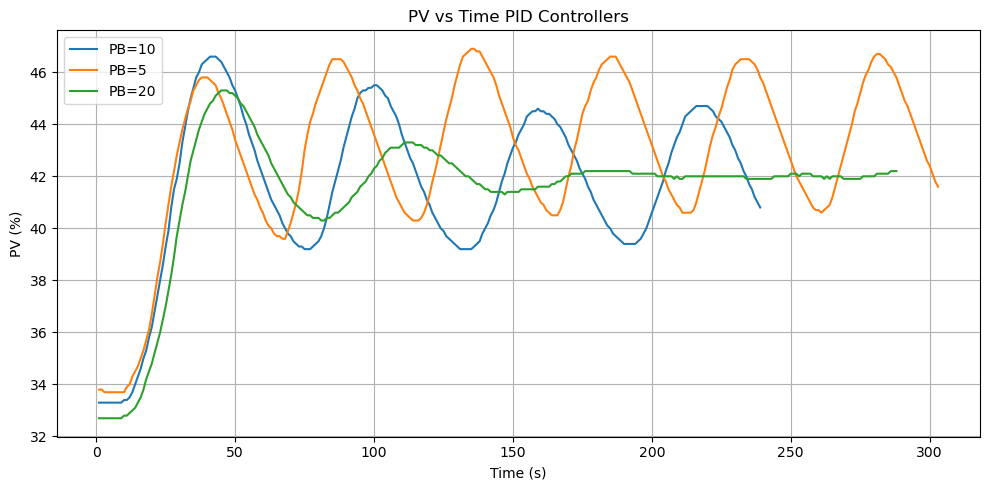

In [106]:
import matplotlib.pyplot as plt

# Load the raw file
with open("1april2025 table 2.csv", "r") as file:
    lines = file.readlines()

# Split sections whenever "Temperature Control Trainer" line appears
sections = []
current_section = []

for line in lines:
    if "Temperature Control Trainer" in line:
        if current_section:
            sections.append(current_section)
        current_section = [line]
    else:
        current_section.append(line)

if current_section:
    sections.append(current_section)

# Labels for controllers
controller_labels = ['PB=10', 'PB=5', 'PB=20']

# Plotting
plt.figure(figsize=(10, 5))

for idx, section in enumerate(sections):
    from io import StringIO
    csv_data = ''.join(section[1:])  # Skip metadata row

    try:
        import pandas as pd
        df = pd.read_csv(StringIO(csv_data))
        df = df[['Time s', 'PV %']].dropna()
        df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
        df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')

        label = controller_labels[idx] if idx < len(controller_labels) else f"Block {idx+1}"
        plt.plot(df['Time s'], df['PV %'], label=label)

    except Exception as e:
        print(f"Error processing section {idx+1}: {e}")

# Axis and labels
plt.xlabel("Time (s)")
plt.ylabel("PV (%)")
plt.title("PV vs Time PID Controllers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


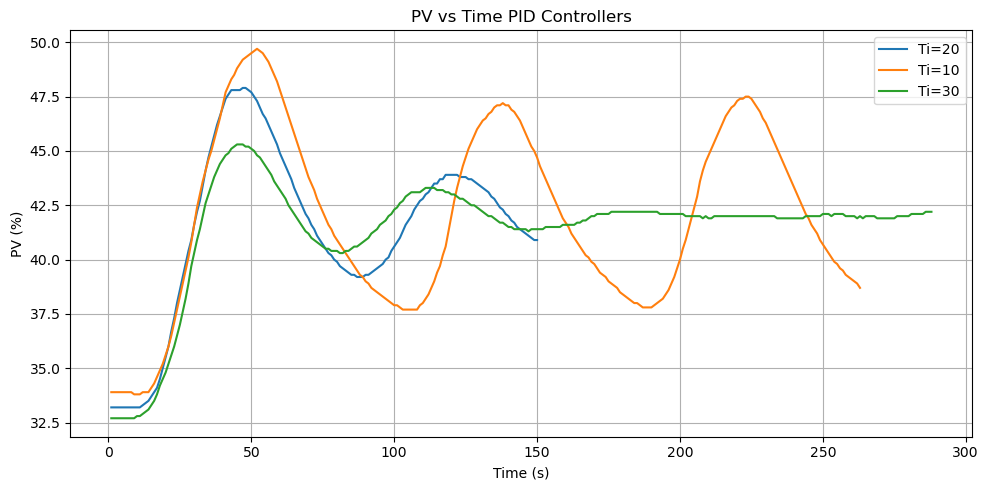

In [110]:
import matplotlib.pyplot as plt

# Load the raw file
with open("1april2025 table 3.csv", "r") as file:
    lines = file.readlines()

# Split sections whenever "Temperature Control Trainer" line appears
sections = []
current_section = []

for line in lines:
    if "Temperature Control Trainer" in line:
        if current_section:
            sections.append(current_section)
        current_section = [line]
    else:
        current_section.append(line)

if current_section:
    sections.append(current_section)

# Labels for controllers
controller_labels = ['Ti=20', 'Ti=10', 'Ti=30']

# Plotting
plt.figure(figsize=(10, 5))

for idx, section in enumerate(sections):
    from io import StringIO
    csv_data = ''.join(section[1:])  # Skip metadata row

    try:
        import pandas as pd
        df = pd.read_csv(StringIO(csv_data))
        df = df[['Time s', 'PV %']].dropna()
        df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
        df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')

        label = controller_labels[idx] if idx < len(controller_labels) else f"Block {idx+1}"
        plt.plot(df['Time s'], df['PV %'], label=label)

    except Exception as e:
        print(f"Error processing section {idx+1}: {e}")

# Axis and labels
plt.xlabel("Time (s)")
plt.ylabel("PV (%)")
plt.title("PV vs Time PID Controllers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


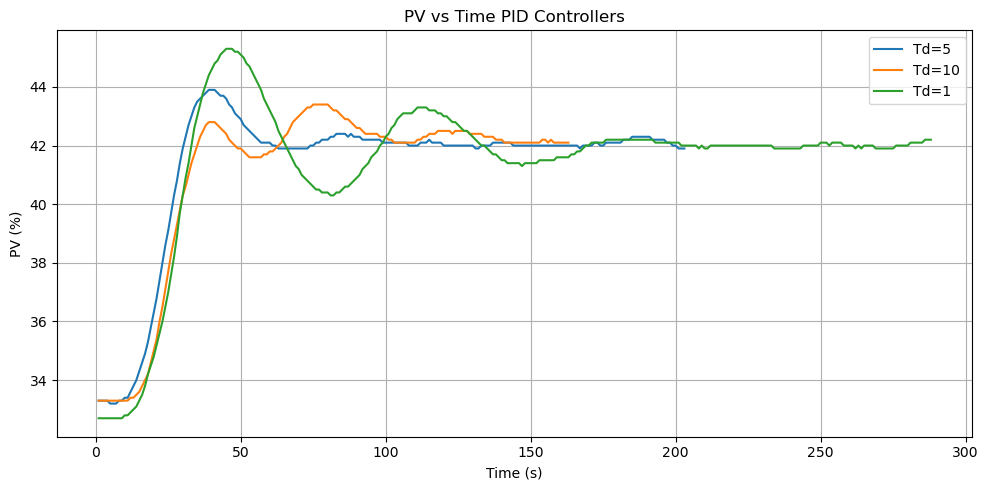

In [109]:
import matplotlib.pyplot as plt

# Load the raw file
with open("1april2025 table4.csv", "r") as file:
    lines = file.readlines()

# Split sections whenever "Temperature Control Trainer" line appears
sections = []
current_section = []

for line in lines:
    if "Temperature Control Trainer" in line:
        if current_section:
            sections.append(current_section)
        current_section = [line]
    else:
        current_section.append(line)

if current_section:
    sections.append(current_section)

# Labels for controllers
controller_labels = ['Td=5', 'Td=10', 'Td=1']

# Plotting
plt.figure(figsize=(10, 5))

for idx, section in enumerate(sections):
    from io import StringIO
    csv_data = ''.join(section[1:])  # Skip metadata row

    try:
        import pandas as pd
        df = pd.read_csv(StringIO(csv_data))
        df = df[['Time s', 'PV %']].dropna()
        df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
        df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')

        label = controller_labels[idx] if idx < len(controller_labels) else f"Block {idx+1}"
        plt.plot(df['Time s'], df['PV %'], label=label)

    except Exception as e:
        print(f"Error processing section {idx+1}: {e}")

# Axis and labels
plt.xlabel("Time (s)")
plt.ylabel("PV (%)")
plt.title("PV vs Time PID Controllers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


P Controller:
  Rise Time     : 20 s
  Overshoot     : 10.24 %
  Offset        : 1.73
  Oscillations  : 3

PI Controller:
  Rise Time     : 29 s
  Overshoot     : 9.52 %
  Offset        : 1.86
  Oscillations  : 5

PD Controller:
  Rise Time     : 18 s
  Overshoot     : 9.52 %
  Offset        : 1.85
  Oscillations  : 1

PID Controller:
  Rise Time     : 26 s
  Overshoot     : 7.86 %
  Offset        : 0.11
  Oscillations  : 1



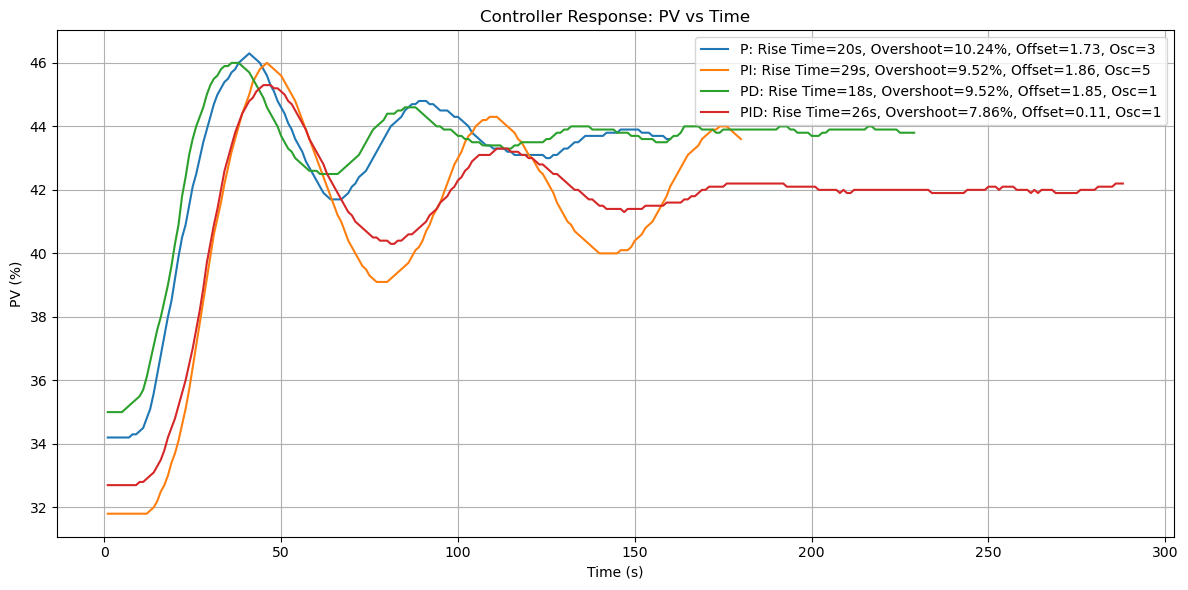

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# Read file
with open("1april2025 p mode.csv", "r") as file:
    lines = file.readlines()

# Split into sections
sections = []
current_section = []

for line in lines:
    if "Temperature Control Trainer" in line:
        if current_section:
            sections.append(current_section)
        current_section = [line]
    else:
        current_section.append(line)

if current_section:
    sections.append(current_section)

controller_labels = ['P', 'PI', 'PD', 'PID']

plt.figure(figsize=(12, 6))

for idx, section in enumerate(sections):
    try:
        csv_data = ''.join(section[1:])
        df = pd.read_csv(StringIO(csv_data))
        df = df[['Time s', 'SP %', 'PV %']].dropna()

        # Convert to numeric
        df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
        df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
        df['SP %'] = pd.to_numeric(df['SP %'], errors='coerce')
        df = df.dropna()

        time = df['Time s'].values
        pv = df['PV %'].values
        sp = df['SP %'].iloc[0]

        # Calculate metrics
        final_pv = pv[-10:].mean()  # use last few values for stable average
        rise_start_val = 0.1 * final_pv
        rise_end_val = 0.9 * final_pv

        try:
            t_start = time[pv >= rise_start_val][0]
            t_end = time[pv >= rise_end_val][0]
            rise_time = round(t_end - t_start, 2)
        except:
            rise_time = "N/A"

        overshoot = round((pv.max() - sp) / sp * 100, 2)
        offset = round(abs(sp - final_pv), 2)

        # Oscillation count: number of times PV crosses SP (zero crossings)
        oscillation_count = ((pv[:-1] - sp) * (pv[1:] - sp) < 0).sum()

        # Plot
        label = controller_labels[idx] if idx < len(controller_labels) else f"Block {idx+1}"
        plt.plot(time, pv, label=f"{label}: Rise Time={rise_time}s, Overshoot={overshoot}%, Offset={offset}, Osc={oscillation_count}")

        # Print stats
        print(f"{label} Controller:")
        print(f"  Rise Time     : {rise_time} s")
        print(f"  Overshoot     : {overshoot} %")
        print(f"  Offset        : {offset}")
        print(f"  Oscillations  : {oscillation_count}\n")

    except Exception as e:
        print(f"Error processing section {idx+1}: {e}")

# Plot formatting
plt.xlabel("Time (s)")
plt.ylabel("PV (%)")
plt.title("Controller Response: PV vs Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


PB=10 Controller:
  Rise Time     : 22 s
  Overshoot     : 10.95 %
  Offset        : 0.14
  Oscillations  : 6

PB=5 Controller:
  Rise Time     : 22 s
  Overshoot     : 11.67 %
  Offset        : 0.8
  Oscillations  : 8

PB=20 Controller:
  Rise Time     : 26 s
  Overshoot     : 7.86 %
  Offset        : 0.11
  Oscillations  : 1



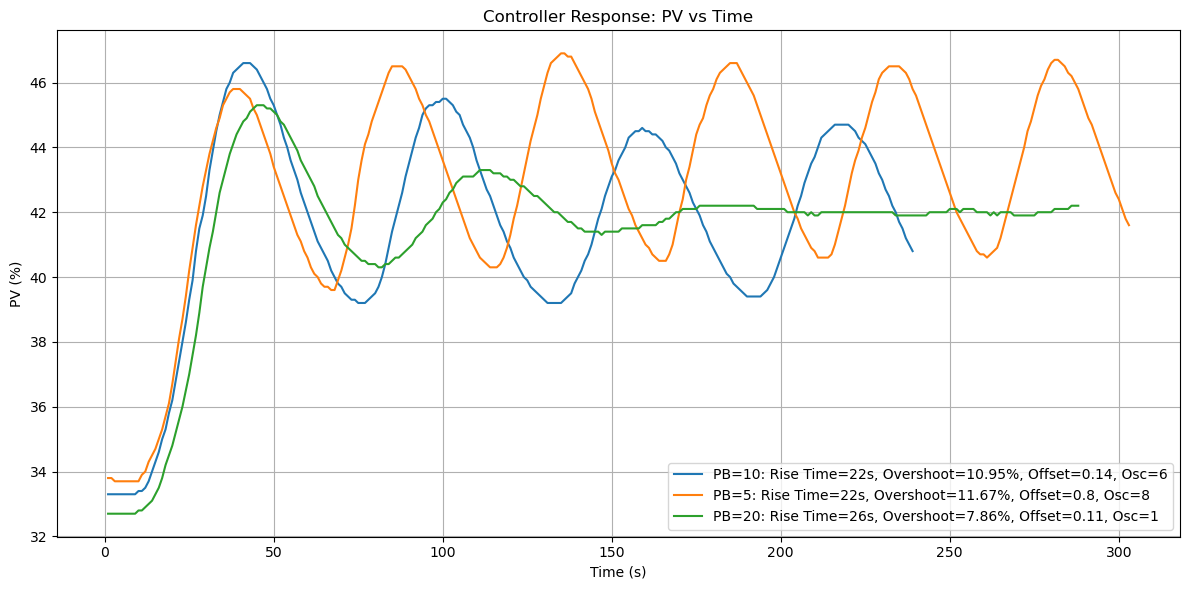

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# Read file
with open("1april2025 table 2.csv", "r") as file:
    lines = file.readlines()

# Split into sections
sections = []
current_section = []

for line in lines:
    if "Temperature Control Trainer" in line:
        if current_section:
            sections.append(current_section)
        current_section = [line]
    else:
        current_section.append(line)

if current_section:
    sections.append(current_section)

controller_labels = ['PB=10', 'PB=5', 'PB=20']

plt.figure(figsize=(12, 6))

for idx, section in enumerate(sections):
    try:
        csv_data = ''.join(section[1:])
        df = pd.read_csv(StringIO(csv_data))
        df = df[['Time s', 'SP %', 'PV %']].dropna()

        # Convert to numeric
        df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
        df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
        df['SP %'] = pd.to_numeric(df['SP %'], errors='coerce')
        df = df.dropna()

        time = df['Time s'].values
        pv = df['PV %'].values
        sp = df['SP %'].iloc[0]

        # Calculate metrics
        final_pv = pv[-10:].mean()  # use last few values for stable average
        rise_start_val = 0.1 * final_pv
        rise_end_val = 0.9 * final_pv

        try:
            t_start = time[pv >= rise_start_val][0]
            t_end = time[pv >= rise_end_val][0]
            rise_time = round(t_end - t_start, 2)
        except:
            rise_time = "N/A"

        overshoot = round((pv.max() - sp) / sp * 100, 2)
        offset = round(abs(sp - final_pv), 2)

        # Oscillation count: number of times PV crosses SP (zero crossings)
        oscillation_count = ((pv[:-1] - sp) * (pv[1:] - sp) < 0).sum()

        # Plot
        label = controller_labels[idx] if idx < len(controller_labels) else f"Block {idx+1}"
        plt.plot(time, pv, label=f"{label}: Rise Time={rise_time}s, Overshoot={overshoot}%, Offset={offset}, Osc={oscillation_count}")

        # Print stats
        print(f"{label} Controller:")
        print(f"  Rise Time     : {rise_time} s")
        print(f"  Overshoot     : {overshoot} %")
        print(f"  Offset        : {offset}")
        print(f"  Oscillations  : {oscillation_count}\n")

    except Exception as e:
        print(f"Error processing section {idx+1}: {e}")

# Plot formatting
plt.xlabel("Time (s)")
plt.ylabel("PV (%)")
plt.title("Controller Response: PV vs Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Ti=20 Controller:
  Rise Time     : 22 s
  Overshoot     : 14.05 %
  Offset        : 0.72
  Oscillations  : 2

Ti=10 Controller:
  Rise Time     : 19 s
  Overshoot     : 18.33 %
  Offset        : 2.7
  Oscillations  : 5

Ti=30 Controller:
  Rise Time     : 26 s
  Overshoot     : 7.86 %
  Offset        : 0.11
  Oscillations  : 1



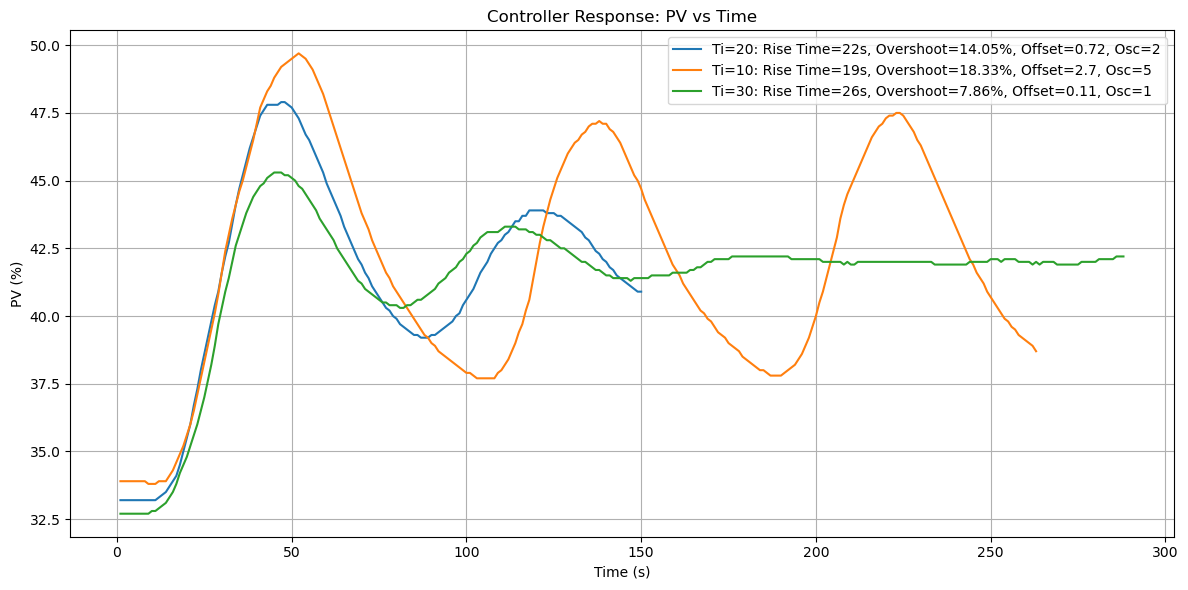

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# Read file
with open("1april2025 table 3.csv", "r") as file:
    lines = file.readlines()

# Split into sections
sections = []
current_section = []

for line in lines:
    if "Temperature Control Trainer" in line:
        if current_section:
            sections.append(current_section)
        current_section = [line]
    else:
        current_section.append(line)

if current_section:
    sections.append(current_section)

controller_labels = ['Ti=20', 'Ti=10', 'Ti=30']

plt.figure(figsize=(12, 6))

for idx, section in enumerate(sections):
    try:
        csv_data = ''.join(section[1:])
        df = pd.read_csv(StringIO(csv_data))
        df = df[['Time s', 'SP %', 'PV %']].dropna()

        # Convert to numeric
        df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
        df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
        df['SP %'] = pd.to_numeric(df['SP %'], errors='coerce')
        df = df.dropna()

        time = df['Time s'].values
        pv = df['PV %'].values
        sp = df['SP %'].iloc[0]

        # Calculate metrics
        final_pv = pv[-10:].mean()  # use last few values for stable average
        rise_start_val = 0.1 * final_pv
        rise_end_val = 0.9 * final_pv

        try:
            t_start = time[pv >= rise_start_val][0]
            t_end = time[pv >= rise_end_val][0]
            rise_time = round(t_end - t_start, 2)
        except:
            rise_time = "N/A"

        overshoot = round((pv.max() - sp) / sp * 100, 2)
        offset = round(abs(sp - final_pv), 2)

        # Oscillation count: number of times PV crosses SP (zero crossings)
        oscillation_count = ((pv[:-1] - sp) * (pv[1:] - sp) < 0).sum()

        # Plot
        label = controller_labels[idx] if idx < len(controller_labels) else f"Block {idx+1}"
        plt.plot(time, pv, label=f"{label}: Rise Time={rise_time}s, Overshoot={overshoot}%, Offset={offset}, Osc={oscillation_count}")

        # Print stats
        print(f"{label} Controller:")
        print(f"  Rise Time     : {rise_time} s")
        print(f"  Overshoot     : {overshoot} %")
        print(f"  Offset        : {offset}")
        print(f"  Oscillations  : {oscillation_count}\n")

    except Exception as e:
        print(f"Error processing section {idx+1}: {e}")

# Plot formatting
plt.xlabel("Time (s)")
plt.ylabel("PV (%)")
plt.title("Controller Response: PV vs Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Td=5 Controller:
  Rise Time     : 22 s
  Overshoot     : 4.52 %
  Offset        : 0.05
  Oscillations  : 1

Td=10 Controller:
  Rise Time     : 25 s
  Overshoot     : 3.33 %
  Offset        : 0.13
  Oscillations  : 0

Td=1 Controller:
  Rise Time     : 26 s
  Overshoot     : 7.86 %
  Offset        : 0.11
  Oscillations  : 1



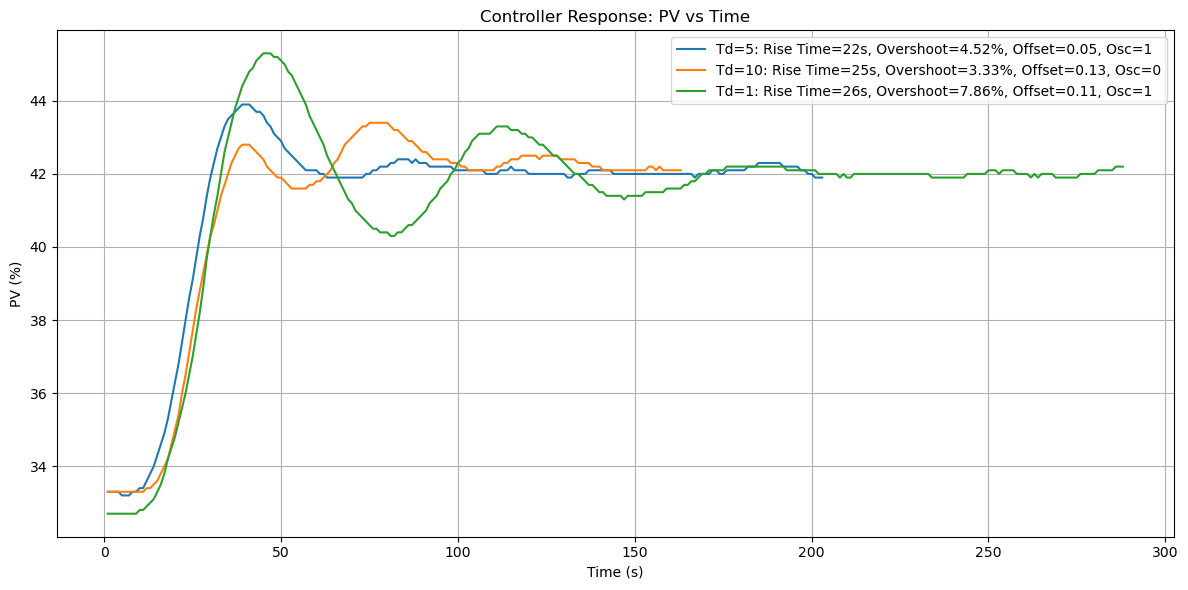

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# Read file
with open("1april2025 table4.csv", "r") as file:
    lines = file.readlines()

# Split into sections
sections = []
current_section = []

for line in lines:
    if "Temperature Control Trainer" in line:
        if current_section:
            sections.append(current_section)
        current_section = [line]
    else:
        current_section.append(line)

if current_section:
    sections.append(current_section)

controller_labels = ['Td=5', 'Td=10', 'Td=1']

plt.figure(figsize=(12, 6))

for idx, section in enumerate(sections):
    try:
        csv_data = ''.join(section[1:])
        df = pd.read_csv(StringIO(csv_data))
        df = df[['Time s', 'SP %', 'PV %']].dropna()

        # Convert to numeric
        df['Time s'] = pd.to_numeric(df['Time s'], errors='coerce')
        df['PV %'] = pd.to_numeric(df['PV %'], errors='coerce')
        df['SP %'] = pd.to_numeric(df['SP %'], errors='coerce')
        df = df.dropna()

        time = df['Time s'].values
        pv = df['PV %'].values
        sp = df['SP %'].iloc[0]

        # Calculate metrics
        final_pv = pv[-10:].mean()  # use last few values for stable average
        rise_start_val = 0.1 * final_pv
        rise_end_val = 0.9 * final_pv

        try:
            t_start = time[pv >= rise_start_val][0]
            t_end = time[pv >= rise_end_val][0]
            rise_time = round(t_end - t_start, 2)
        except:
            rise_time = "N/A"

        overshoot = round((pv.max() - sp) / sp * 100, 2)
        offset = round(abs(sp - final_pv), 2)

        # Oscillation count: number of times PV crosses SP (zero crossings)
        oscillation_count = ((pv[:-1] - sp) * (pv[1:] - sp) < 0).sum()

        # Plot
        label = controller_labels[idx] if idx < len(controller_labels) else f"Block {idx+1}"
        plt.plot(time, pv, label=f"{label}: Rise Time={rise_time}s, Overshoot={overshoot}%, Offset={offset}, Osc={oscillation_count}")

        # Print stats
        print(f"{label} Controller:")
        print(f"  Rise Time     : {rise_time} s")
        print(f"  Overshoot     : {overshoot} %")
        print(f"  Offset        : {offset}")
        print(f"  Oscillations  : {oscillation_count}\n")

    except Exception as e:
        print(f"Error processing section {idx+1}: {e}")

# Plot formatting
plt.xlabel("Time (s)")
plt.ylabel("PV (%)")
plt.title("Controller Response: PV vs Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
